**A Generalized Kruskal Algorithm**

In [1]:
class Kruskal:

    def __init__(self, num_nodes):
        # num_nodes = total number of nodes in the graph
        self.num_nodes = num_nodes

        # initialize empty list to hold edges represented by the tuple (u, v, weight)
        # u, v are the nodes connected by the edge and weight is the cost of that edge in the problem
        self.edges = []

        # used later to determine the roots of sets of nodes to avoid cycles
        # also can be used to merge sets and connect nodes
        self.parent = list(range(num_nodes))
        self.rank = [0] * num_nodes

        self.mst = []  # list to store edges in the MST
        self.total_cost = 0  # total cost of the MST

    # will be used in the union function to determine which set the current node belongs to
    def find(self, node):
        # check if the current node is its own parent
        if self.parent[node] != node:  # if it is not the parent
            self.parent[node] = self.find(self.parent[node])  # calls the function recursively to find the current node's parent until reaching the root
        return self.parent[node]  # if it is the parent, stop and return the node as the root of the set

    # will be used later to merge sets for two nodes after adding an edge
    def union(self, node1, node2):
        root1 = self.find(node1)  # finds the root of the set for node 1
        root2 = self.find(node2)  # finds the root of the set for node 2

        # if the nodes are not in the same sets, merge according to their ranks
        if root1 != root2:
            # if the height of the set of root 1 is greater, make it the parent
            if self.rank[root1] > self.rank[root2]:
                self.parent[root2] = root1
            elif self.rank[root1] < self.rank[root2]:
                self.parent[root1] = root2
            else:
                self.parent[root2] = root1
                self.rank[root1] += 1

    # add a new node to the graph
    def add_node(self):
        self.num_nodes += 1
        self.parent.append(self.num_nodes - 1)
        self.rank.append(0)

    # delete a node and all its edges from the graph
    def delete_node(self, node):
        # remove all edges connected to the given node
        self.edges = [edge for edge in self.edges if node not in edge[:2]]
        self.num_nodes -= 1
        self.parent = list(range(self.num_nodes))
        self.rank = [0] * self.num_nodes

    # allows for updates in edges
    def update_edge(self, u, v, new_weight):
        # loop through all existing edges
        for i, edge in enumerate(self.edges):
            # check if the current edge matches the edge(u, v) in either direction
            if (edge[0] == u and edge[1] == v) or (edge[0] == v and edge[1] == u):
                # update the weight of the edge
                self.edges[i] = (u, v, new_weight)
                return
        # if the edge doesn't exist, add it
        self.edges.append((u, v, new_weight))
        self.remove_duplicate_edges()

    # remove an edge with nodes u and v from the graph
    def delete_edge(self, u, v):
        # remove the edge from the list of edges
        self.edges = [edge for edge in self.edges if not ((edge[0] == u and edge[1] == v) or (edge[0] == v and edge[1] == u))]
        # recompute the MST after deleting the edge
        self.compute()

    # remove any duplicate edges
    def remove_duplicate_edges(self):
        unique_edges = set()
        cleaned_edges = []
        for u, v, weight in self.edges:
            edge = tuple(sorted((u, v))) + (weight,)  # ensure the edge is unique
            if edge not in unique_edges:
                unique_edges.add(edge)
                cleaned_edges.append((u, v, weight))  # add the unique edge to the cleaned list
        self.edges = cleaned_edges

    # Update the algorithm when a new edge is added with (u, v, weight)
    def _incremental_mst_update(self, u, v, weight):
        if self.find(u) != self.find(v):  # if adding the edge doesn't form a cycle
            self.union(u, v)  # connect u and v
            self.mst.append((u, v, weight))  # add the new edge and its weight to mst and total cost
            self.total_cost += weight
        else:
            # check if the new edge can replace an existing edge in the MST
            replaced = False

            for i, (x, y, w) in enumerate(self.mst):
                # find the edge forming a temporary cycle with the new edge
                if (x == u and y == v) or (x == v and y == u):  # Match the existing edge
                    if weight < w:  # New edge has a lower weight
                        self.mst[i] = (u, v, weight)  # replace the heavier edge
                        self.total_cost += weight - w  # update the total cost
                        replaced = True
                        break

            # if no replacement was made, recompute the MST
            if not replaced:
                self.compute()

    # this function will return the list of edges in the minimum spanning tree and the total cost of the MST
    def compute(self):
        # sort edges by weight since Kruskal’s Algorithm processes edges in order of increasing weight
        self.edges.sort(key=lambda x: x[2])

        # create a parent array in which each node is initialized as its own parent and has its own set
        self.parent = list(range(self.num_nodes))
        self.rank = [0] * self.num_nodes

        self.mst = []  # reset MST
        self.total_cost = 0  # reset total cost

        # loop through the sorted edges
        for u, v, weight in self.edges:
            # call the find function to check the roots of the sets of u, v
            # they need to be different because if u and v are in the same set, adding an edge will form a cycle
            if self.find(u) != self.find(v):
                self.union(u, v)  # call the union function to merge the two sets
                self.mst.append((u, v, weight))  # add the edge to the MST list
                self.total_cost += weight  # add the weight of the edge to total cost

        return self.mst, self.total_cost  # return the total list of edges added in MST and the total cost

    # Print the results
    def print_mst(self):
        # compute the MST and update total cost
        self.mst, self.total_cost = self.compute()
        print("Minimum Spanning Tree:")
        for u, v, weight in self.mst:
            print(f"Edge ({u}, {v}) with cost {weight}")
        print(f"Total Cost: {self.total_cost}")


**Example Problem - Initial Network**

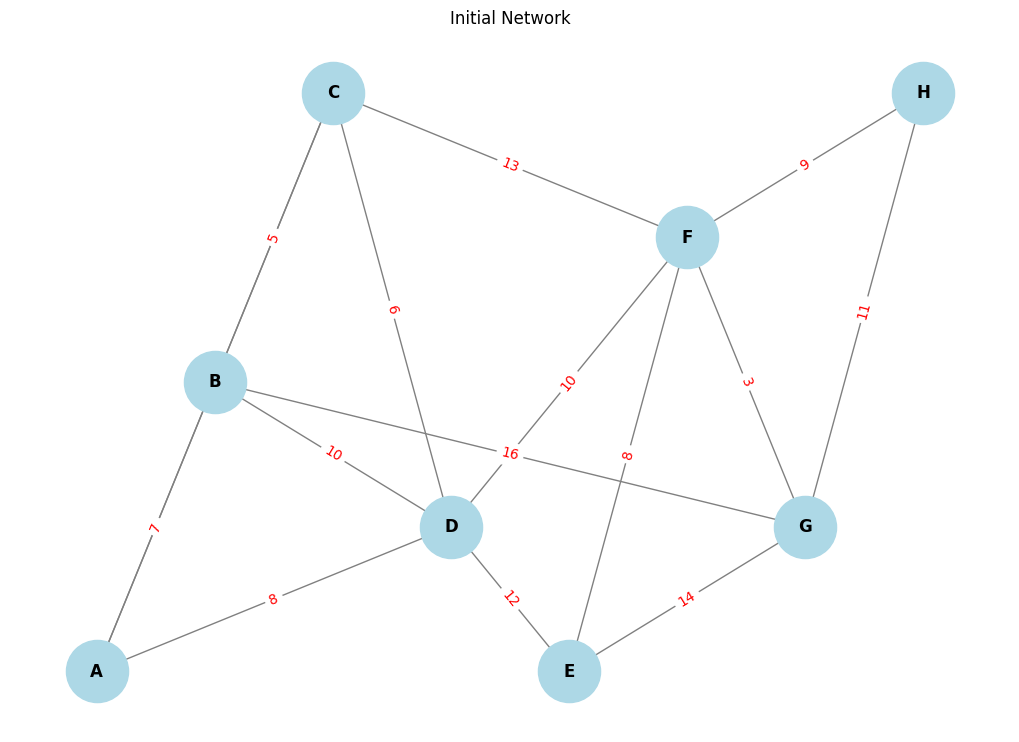

In [16]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_initial_network(title, edges, city_map, node_positions):
    # Create a graph
    G = nx.Graph()

    # Add edges to the graph
    for u, v, weight in edges:
        G.add_edge(list(city_map.keys())[u], list(city_map.keys())[v], weight=weight)

    # Draw the graph
    edge_labels = nx.get_edge_attributes(G, "weight")

    plt.figure(figsize=(10, 7))
    nx.draw(G, node_positions, with_labels=True, node_color="lightblue", node_size=2000, font_size=12, font_weight="bold", edge_color="gray")
    nx.draw_networkx_edge_labels(G, node_positions, edge_labels=edge_labels, font_color="red", font_size=10)
    plt.title(title)
    plt.show()

node_positions = {
    "A": (0, 0),
    "B": (1, 2),
    "C": (2, 4),
    "D": (3, 1),
    "E": (4, 0),
    "F": (5, 3),
    "G": (6, 1),
    "H": (7, 4),
}

initial_edges = [
    ("A", "B", 7), ("A", "C", 15), ("B", "C", 5), ("B", "D", 10), ("C", "D", 6),
    ("D", "E", 12), ("E", "F", 8), ("F", "G", 3), ("E", "G", 14), ("G", "H", 11),
    ("H", "F", 9), ("C", "F", 13), ("B", "G", 16), ("A", "D", 8), ("D", "F", 10)
]

# Map cities to indices
city_map = {city: i for i, city in enumerate("ABCDEFGH")}

# Convert edges to use indices
indexed_edges = [(city_map[u], city_map[v], weight) for u, v, weight in initial_edges]

# Visualize the initial network
visualize_initial_network("Initial Network", indexed_edges, city_map, node_positions)

**Solve the MST using the optimization model**

In [74]:
kruskal_model = Kruskal(num_nodes=len(node_positions))

# Add edges to the solver
for u, v, weight in indexed_edges:
    kruskal_model.update_edge(u, v, weight)

# Compute the MST
mst, total_cost = kruskal_model.compute()

print("Computed MST:")
kruskal_model.print_mst()

Computed MST:
Minimum Spanning Tree:
Edge (5, 6) with cost 3
Edge (1, 2) with cost 5
Edge (2, 3) with cost 6
Edge (0, 1) with cost 7
Edge (4, 5) with cost 8
Edge (7, 5) with cost 9
Edge (3, 5) with cost 10
Total Cost: 48


**Pre-define a visualization function. Visualize the original MST.**

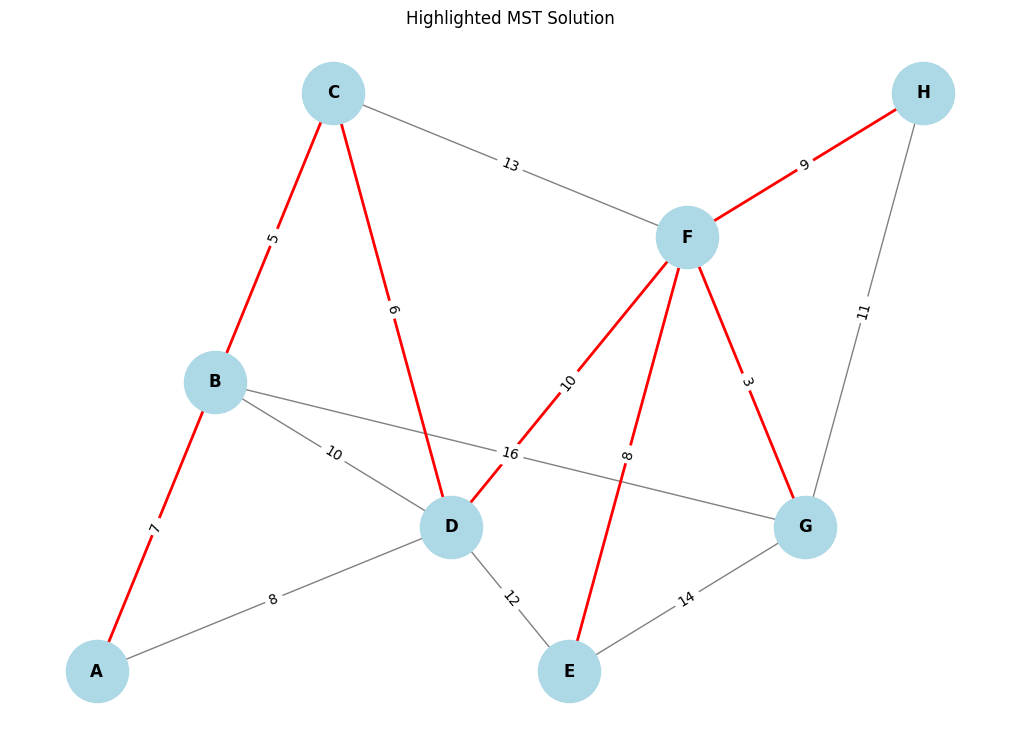

In [64]:
def visualize_mst_solution(title, mst_edges, city_map, node_positions):
    G = nx.Graph()

    # Add all edges for visualization (to display the full graph)
    for u, v, weight in kruskal_model.edges:
        G.add_edge(list(city_map.keys())[u], list(city_map.keys())[v], weight=weight)

    # Highlight only MST edges
    mst_edges_highlight = [
        (list(city_map.keys())[u], list(city_map.keys())[v]) for u, v, _ in mst_edges
    ]

    pos = node_positions
    edge_labels = nx.get_edge_attributes(G, "weight")

    plt.figure(figsize=(10, 7))
    nx.draw(
        G, pos, with_labels=True, node_color="lightblue", node_size=2000,
        font_size=12, font_weight="bold", edge_color="gray"
    )
    nx.draw_networkx_edges(
        G, pos, edgelist=mst_edges_highlight, edge_color="red", width=2
    )
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="black", font_size=10)
    plt.title(title)
    plt.show()

# Visualize the MST with paths highlighted
visualize_mst_solution(
    "Highlighted MST Solution", mst, city_map, node_positions
)

**Re-Optimize after change in costs:**
The cost of the connection between D and E increases from 12 to 18 due to difficult terrain. The cost of the connection between C and F decreases from 13 to 6 after a new efficient route is discovered.

In [75]:
kruskal_model.update_edge(city_map["D"], city_map["E"], 18)
kruskal_model.update_edge(city_map["C"], city_map["F"], 6)

# remove duplicate edges and re-optimize
kruskal_model.remove_duplicate_edges()
mst_new_cost, total_cost = kruskal_model.compute()
print("Updated MST after cost changes:")
kruskal_model.print_mst()

Updated MST after cost changes:
Minimum Spanning Tree:
Edge (5, 6) with cost 3
Edge (1, 2) with cost 5
Edge (2, 3) with cost 6
Edge (2, 5) with cost 6
Edge (0, 1) with cost 7
Edge (4, 5) with cost 8
Edge (7, 5) with cost 9
Total Cost: 44


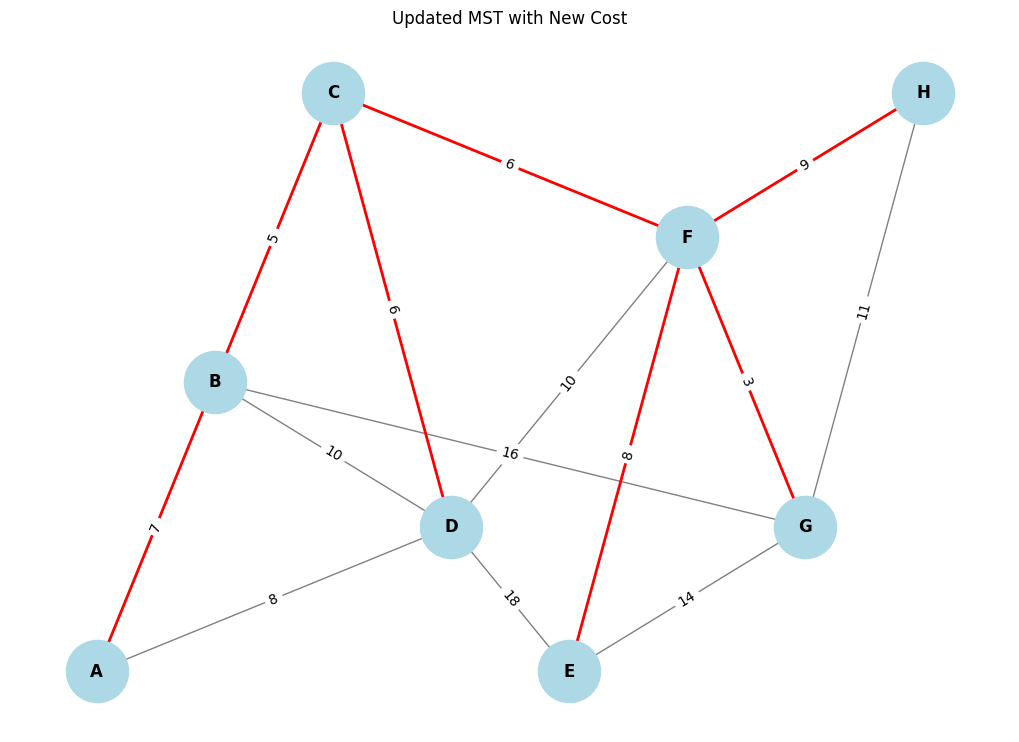

In [76]:
visualize_mst_solution("Updated MST with New Cost", mst_new_cost, city_map, node_positions)

**New City: City I is added** at position (8, 3) **with new Connections**:
("H", "I", 9)
("F", "I", 5)
("G", "I", 14)

In [70]:
new_city = "I"
new_city_position = (8, 3)
new_edges = [("H", "I", 9), ("F", "I", 5), ("G", "I", 14)]

node_positions[new_city] = new_city_position
kruskal_model.add_node()

# Update city map to include the new city
city_map = {city: i for i, city in enumerate(node_positions.keys())}

# Add new connections for the new city
for u, v, weight in new_edges:
    kruskal_model.update_edge(city_map[u], city_map[v], weight)

kruskal_model.remove_duplicate_edges()
mst_new_city, total_cost = kruskal_model.compute()

print("Updated MST after adding new city:")
kruskal_model.print_mst()

Updated MST after cleaning duplicates and adding new city:
Minimum Spanning Tree:
Edge (5, 6) with cost 3
Edge (1, 2) with cost 5
Edge (5, 8) with cost 5
Edge (2, 3) with cost 6
Edge (0, 1) with cost 7
Edge (4, 5) with cost 8
Edge (7, 5) with cost 9
Edge (3, 5) with cost 10
Total Cost: 53


**Visualize the updated MST with the new city I**

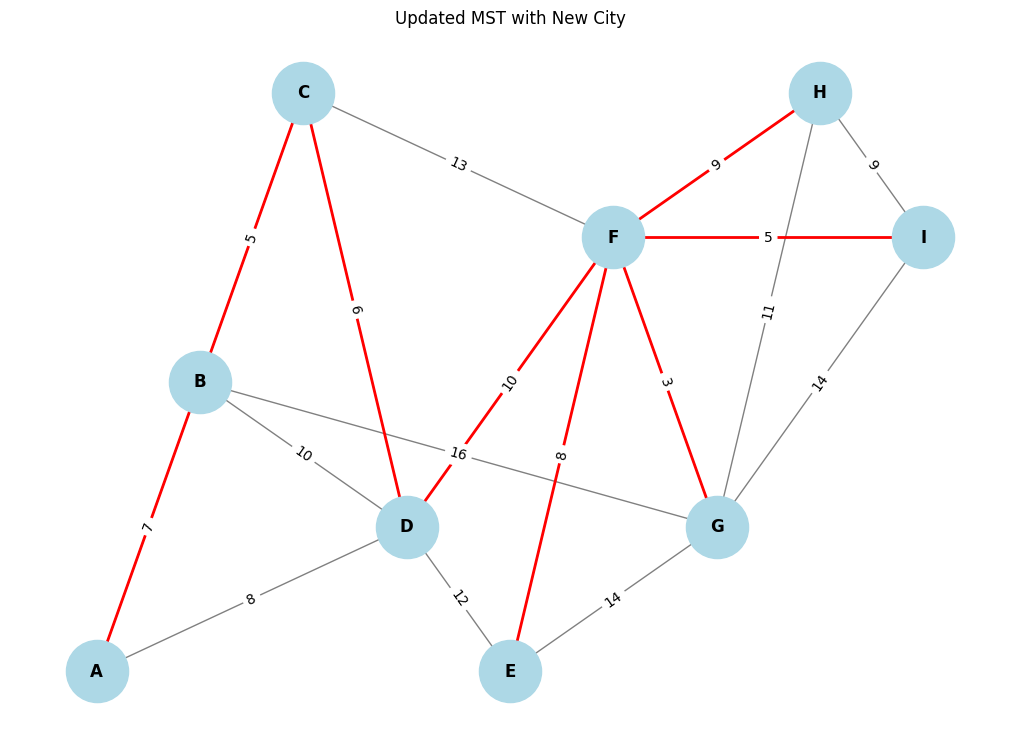

In [68]:
visualize_mst_solution("Updated MST with New City", mst_new_city, city_map, node_positions)